# Working with Census Geographies

morpc-census provides tools to fetch Census geometries and data for specific places at specific resolutions. Every query is defined by two things:

- **Scope** — *where* (Franklin County, the 15-county MORPC region, the state of Ohio)
- **SumLevel** — *at what resolution* (county, census tract, place)

The results come back with a **GEOIDFQ** — a fully-qualified geographic identifier — for each geography returned.

In [53]:
from morpc_census import (
    SCOPES, Scope, SumLevel, GeoIDFQ,
    geoinfo_from_scope_sumlevel, geoids_from_scope,
    fetch_geos_from_sumlevel_scope,
)

## 1. Scopes — choosing where

A scope names a geographic extent. morpc-census ships with built-in scopes for the US, all 50 states, all Ohio counties, and several MORPC regions.

In [54]:
# See all available scope names
list(SCOPES.keys())

['us',
 'columbuscbsa',
 'alabama',
 'alaska',
 'arizona',
 'arkansas',
 'california',
 'colorado',
 'connecticut',
 'delaware',
 'district of columbia',
 'florida',
 'georgia',
 'hawaii',
 'idaho',
 'illinois',
 'indiana',
 'iowa',
 'kansas',
 'kentucky',
 'louisiana',
 'maine',
 'maryland',
 'massachusetts',
 'michigan',
 'minnesota',
 'mississippi',
 'missouri',
 'montana',
 'nebraska',
 'nevada',
 'new hampshire',
 'new jersey',
 'new mexico',
 'new york',
 'north carolina',
 'north dakota',
 'ohio',
 'oklahoma',
 'oregon',
 'pennsylvania',
 'rhode island',
 'south carolina',
 'south dakota',
 'tennessee',
 'texas',
 'utah',
 'vermont',
 'virginia',
 'washington',
 'west virginia',
 'wisconsin',
 'wyoming',
 'puerto rico',
 'lake',
 'hancock',
 'allen',
 'morgan',
 'portage',
 'butler',
 'fayette',
 'vinton',
 'paulding',
 'scioto',
 'fulton',
 'henry',
 'logan',
 'brown',
 'monroe',
 'trumbull',
 'pike',
 'pickaway',
 'muskingum',
 'lawrence',
 'adams',
 'crawford',
 'guernsey',
 

Select scopes from the predetermined list

In [55]:
# Look up a specific scope
SCOPES["franklin"]

Scope(name='franklin', for_param='county:049', in_param='state:39')

In [56]:
# The 15-county MORPC region covers multiple counties — for_param holds their FIPS codes
SCOPES["region15"]

Scope(name='region15', for_param='county:041,045,049,089,097,129,159,083,101,117,047,073,091,127,141', in_param='state:39')

In [57]:
region15 = Scope('region15')

In [58]:
region15.params

{'for': 'county:041,045,049,089,097,129,159,083,101,117,047,073,091,127,141',
 'in': 'state:39'}

In [59]:
region15.sql

"COUNTY in ('041','045','049','089','097','129','159','083','101','117','047','073','091','127','141') and STATE in ('39')"

## 2. Summary levels — choosing resolution

A `SumLevel` pairs a Census query name (e.g. `"county"`) with its three-digit summary level code (e.g. `"050"`). Construct one from either form — the other field is filled in automatically.

Optional metadata fields (`singular`, `plural`, `hierarchy_string`, `tigerweb_name`) default to `None` and can be supplied when the full description is needed.

In [71]:
# Construct from a query name — three-digit code is filled in automatically
SumLevel("county")

'050'

In [72]:
# Construct from a three-digit code — query name is filled in automatically; same result
SumLevel("050")

'050'

In [73]:
# Optional metadata fields default to None when constructing by name or code alone
sl = SumLevel("county")
print(sl.name, sl.sumlevel, sl.singular, sl.plural, sl.hierarchy_string, sl.tigerweb_name, sl.current_variant)

county 050 county counties COUNTY counties 00


In [74]:
sl

'050'

In [75]:
# Supply metadata explicitly when the full description is needed
SumLevel(
    name="county", sumlevel="050",
    singular="county", plural="counties",
    hierarchy_string="COUNTY", tigerweb_name="counties",
    current_variant='00'
)

'050'

In [65]:
# Unrecognized names or codes raise a ValueError listing available options
try:
    SumLevel("neighborhood")
except ValueError as e:
    print(e)

Sumlevel 'neighborhood' not recognized. Available: ['us', 'region', 'division', 'state', 'county', 'county subdivision', 'place/remainder (or part)', 'block', 'tract', 'block group', 'county (or part)', 'place', 'metropolitan statistical area/micropolitan statistical area', 'combined statistical area', 'urban area', 'congressional district', 'state legislative district (upper chamber)', 'state legislative district (lower chamber)', 'public use microdata area', 'zip code tabulation area', 'school district (elementry)', 'school district (secondary)', 'school district (unified)', 'region15', 'region10', 'region7', 'regioncorpo', 'regionceds', 'regionmpo', 'regiontdm', 'regiononecbus']


## 3. Querying geographic IDs

`geoinfo_from_scope_sumlevel` queries the Census geographic info API and returns GEOIDFQs for every geography in a scope at a given resolution — without downloading geometry data. Use it when you want to enumerate geographies, check what's in a scope, or collect IDs to pass to other Census queries.

It accepts either string names or class instances for both `scope` and `sumlevel`.

> **Network required** — cells below make live calls to the Census API.

In [ ]:
# Get GEOIDFQs for all counties in the 15-county MORPC region
# When sumlevel is omitted, the scope's native level is used
geoinfo_from_scope_sumlevel("region15")

In [ ]:
# Get the same result as a DataFrame (GEO_ID and NAME columns)
geoinfo_from_scope_sumlevel("region15", output="table")

In [ ]:
# Drill down to a finer resolution: census tracts within Franklin County
geoinfo_from_scope_sumlevel("franklin", "tract", output="table")

In [ ]:
# Scope and SumLevel objects can be passed directly
franklin = Scope("franklin")
tract = SumLevel("tract")
geoinfo_from_scope_sumlevel(franklin, tract, output="table")

### `geoids_from_scope`

`geoids_from_scope` is a lower-level helper that returns GEOIDFQs for the geographies that *define* a scope — the actual counties, CBSAs, or other units that the scope is built from. Unlike `geoinfo_from_scope_sumlevel`, it does not accept a `sumlevel` argument.

In [ ]:
# Get the defining GEOIDFQs for the franklin scope (the county itself)
geoids_from_scope("franklin")

In [ ]:
# The region15 scope is defined by 15 county GEOIDFQs
geoids_from_scope("region15")

In [ ]:
# Each GEOIDFQ can be parsed to inspect its components
GeoIDFQ.parse(geoids_from_scope("franklin")[0])

## 4. Fetching geometries

`fetch_geos_from_sumlevel_scope(scope, scale)` is the primary function for downloading spatial data. Pass a scope name and an optional scale name — it returns a GeoDataFrame.

> **Network required** — the cells below make live calls to the Census API and TIGERweb REST API.

In [66]:
# Get county boundaries for the 15-county MORPC region
# Omitting scale returns geographies at the scope's own level (counties)
region_counties = fetch_geos_from_sumlevel_scope(scope="region15")
region_counties


Downloading: 100%|██████████████████████████| 1/1 [00:01<00:00, 1.76 requests/s]


,GEO_ID,geometry,NAME,state,county,GEOIDFQ
0,39101,"POLYGON ((-83.18826 40.70214, -83.18888 40.702...","Marion County, Ohio",39,101,0500000US39101
1,39045,"POLYGON ((-82.49033 39.6617, -82.48837 39.6615...","Fairfield County, Ohio",39,045,0500000US39045
2,39159,"POLYGON ((-83.17128 40.19808, -83.17137 40.201...","Union County, Ohio",39,159,0500000US39159
3,39089,"POLYGON ((-82.46276 40.24515, -82.47418 40.245...","Licking County, Ohio",39,089,0500000US39089
4,39073,"POLYGON ((-82.40223 39.39023, -82.40107 39.390...","Hocking County, Ohio",39,073,0500000US39073
5,39127,"POLYGON ((-82.47235 39.83884, -82.4724 39.8372...","Perry County, Ohio",39,127,0500000US39127
6,39141,"POLYGON ((-82.9982 39.48006, -82.9982 39.48036...","Ross County, Ohio",39,141,0500000US39141
7,39083,"POLYGON ((-82.18818 40.38335, -82.18795 40.387...","Knox County, Ohio",39,083,0500000US39083
8,39097,"POLYGON ((-83.20952 40.07514, -83.20788 40.092...","Madison County, Ohio",39,097,0500000US39097
9,39047,"POLYGON ((-83.37271 39.37742, -83.37267 39.377...","Fayette County, Ohio",39,047,0500000US39047


<Axes: >

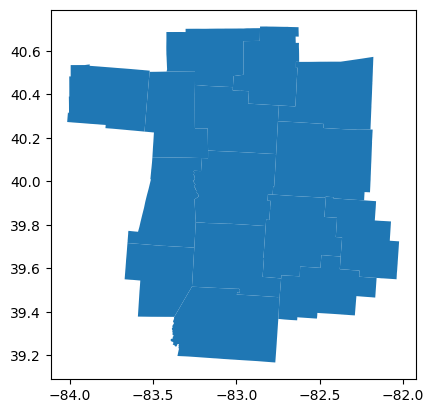

In [67]:
region_counties.plot()


Downloading: 100%|██████████████████████████| 1/1 [00:01<00:00, 0.93 requests/s]


<Axes: >

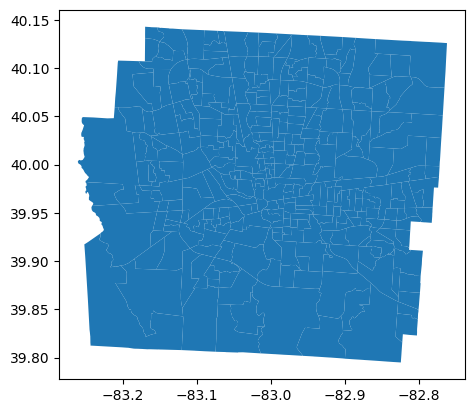

In [68]:
# Get all census tracts within Franklin County
franklin_tracts = fetch_geos_from_sumlevel_scope(scope="franklin", sumlevel="tract")
franklin_tracts.plot()

## 5. Working with GEOIDFQs

Every geography returned by the Census API has a **GEOIDFQ** (fully-qualified geographic identifier) — a string that encodes the geography type and its component codes.

For example, `1400000US39041010100` is the GEOIDFQ for census tract 101 in Delaware County, Ohio:

```
140  00  00  US  39    041     010100
─┬─  ─┬  ─┬  ─┬  ─┬─  ─┬─    ──┬──
 │    │   │   │   │    │       tract
 │    │   │   │   │    county
 │    │   │   │   state
 │    │   │   literal
 │    │   geocomp
 │    variant
 sumlevel (140 = census tract)
```

`GeoIDFQ` lets you parse, inspect, and construct these strings.

In [70]:
# Parse a GEOIDFQ returned by the Census API
tract = GeoIDFQ.parse("1400000US39041010100")
tract

GeoIDFQ(sumlevel='140', variant='00', geocomp='00', parts={'state': '39', 'tract': '041010'})

In [34]:
tract.sumlevel.name

'tract'

In [35]:
tract.sumlevel.hierarchy_string

'COUNTY-TRACT'

In [36]:
# Geographic components are accessible as direct attributes
print(tract.state, tract.county, tract.tract)

# .parts returns the same data as a dict (backward-compatible)
tract.parts

{'state': '39', 'tract': '041010'}

In [16]:
# .geoid is the short-form ID used in REST API queries (the part after 'US')
tract.geoid

'39041010'

In [19]:
# Build a GEOIDFQ from component codes using keyword arguments
county = GeoIDFQ.build("050", state="39", county="049")
str(county)    # Franklin County, Ohio

'0500000US39049'

In [20]:
# For geographies with variant codes, pass variant explicitly
# Variant = Congress number minus 100, so the 119th Congress = "19"
cd = GeoIDFQ.build("500", variant="19", state="39", cd="12")
str(cd)    # Ohio's 12th Congressional District, 119th Congress

'5001900US3912'

In [21]:
# GEOIDFQs from a fetch can be parsed directly from the GEO_ID column
# (network required — uses region_counties from section 4)
geoidfqs = region_counties["GEOIDFQ"].tolist()
parsed = [GeoIDFQ.parse(g) for g in geoidfqs]

# Access geographic components as direct attributes
[(g.state, g.county) for g in parsed]

NameError: name 'region_counties' is not defined